**Proje Konusu: YSA’ların sınırları**

25*25’lik binary bir matris girişine karşılık aşağıdaki çıktıları üreten 5 YSA eğitiniz.

- A) Matriste 5 nokta (rasgele konumlarda) bulunmaktadır. Model bu noktalardan birbirine en yakın olan ikisi arasındaki Manhattan mesafesini çıktı olarak verecektir. 
- B) A’nin aynısı sadece en yakın yerine en uzak olan ikisi… 
- C) Matriste değişken sayıda (her girişte farklı sayıda olabilir) N adet (1 10 arası) nokta (rasgele konumlarda) bulunmaktadır. Model nokta sayısını çıktı olarak verecektir. 
- D) C’nin aynısı ama çıkış, nokta sayısının tek mi çift mi olduğu 
- E) C’nin aynısı ama çıkış, nokta sayısı tek ise sol üst köşeye en yakın olan noktanın sol üst köşeye Manhattan mesafesi, çift ise sağ alt köşeye en yakın olan noktanın sağ alt köşeye Manhattan mesafesi

YSA modeli olarak RNN, MLP, CNN, Transformer vb. istediğinizi kullanabilirsiniz.<br> 
Her problemde farklı birini de aynılarını da kullanabilirsiniz.

- 5 problemin her biri için: En az 800 örneğe sahip eğitim, 200 örneğe sahip test kümesi oluşturunuz.
- Her eğitim ve test kümesinde çıkışların dağılımı eşit olmalıdır. Örneğin A’da aradaki mesafeler 1-50 aralığında değişiyorsa her aralıktan eşit sayıda örnek olmalıdır. Kümeler buna göre oluşturulmalıdır.
- YSA ların hiperparametre optimizasyonunu nasıl yaptığınızı raporlayınız.
- Eğitim kümesinin çeyrek, yarım ve tam halleri için eğitim yapıp test kümesi üzerindeki performansını raporlayınız.
- Yanlış ve doğru yapılan test örneklerini kendi gözünüzle inceleyip, modellerin neyi öğrenebildiğini / öğrenemediğini yorumlayınız.
- Bulgularınızı tablolar ve grafiklerle sunun, yorumlayın.

In [121]:
import numpy as np
import matplotlib.pyplot as plt

In [122]:
# Manhattan distance
def manhattan(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

In [134]:
def load_dataset(problem_name, folder_name="data"):
    """
    Belirtilen probleme ait veri setini (.npy dosyalarından) belleğe yükler.
    
    Argümanlar:
        problem_name (str): Yüklenecek problem etiketi ('A', 'B', 'C', 'D', 'E').
        folder_name (str): .npy dosyalarının bulunduğu dizin.
        
    Dönüş Değerleri:
        xTrain, yTrain, xTest, yTest (numpy.ndarray)
    """
    # Girdi standardizasyonu (küçük harf girilirse büyüt)
    problem_name = str(problem_name).upper()
    
    if problem_name not in ['A', 'B', 'C', 'D', 'E']:
        raise ValueError("Geçersiz problem adı! Lütfen 'A', 'B', 'C', 'D' veya 'E' kullanın.")

    x_train_path = os.path.join(folder_name, f"x_train_{problem_name}.npy")
    y_train_path = os.path.join(folder_name, f"y_train_{problem_name}.npy")
    x_test_path  = os.path.join(folder_name, f"x_test_{problem_name}.npy")
    y_test_path  = os.path.join(folder_name, f"y_test_{problem_name}.npy")

    try:
        x_train = np.load(x_train_path)
        y_train = np.load(y_train_path)
        x_test  = np.load(x_test_path)
        y_test  = np.load(y_test_path)
        
        print(f"[+] Problem {problem_name} veri seti başarıyla yüklendi.")
        print(f"    Train -> X: {x_train.shape}, y: {y_train.shape}")
        print(f"    Test  -> X: {x_test.shape}, y: {y_test.shape}")
        
        return x_train, y_train, x_test, y_test
        
    except FileNotFoundError as e:
        print(f"\n[!] HATA: '{folder_name}' dizininde Problem {problem_name} dosyaları bulunamadı.")
        print("[!] Lütfen önce 'TargetDrivenDatasetGenerator' ile verileri ürettiğinizden emin olun.")
        raise e

In [161]:
def plot_mat(matrix):
    size = matrix.shape[0]  # 25 varsaymıyoruz, genelleştirdim
    
    fig, ax = plt.subplots(figsize=(6, 6))

    # 1'leri siyah, 0'ları beyaz
    ax.imshow(matrix, cmap="Greys", interpolation="none")

    # GRID (hücre çizgileri)
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)

    # KOORDİNATLAR
    ax.set_xticks(np.arange(size))
    ax.set_yticks(np.arange(size))
    ax.set_xticklabels(np.arange(size))
    ax.set_yticklabels(np.arange(size))

    # daha okunaklı
    ax.tick_params(axis='both', labelsize=8)

    # matrix gibi görünmesi için (0,0 üst sol)
    ax.invert_yaxis()

    plt.show()

[+] Problem E veri seti başarıyla yüklendi.
    Train -> X: (960, 25, 25), y: (960,)
    Test  -> X: (240, 25, 25), y: (240,)


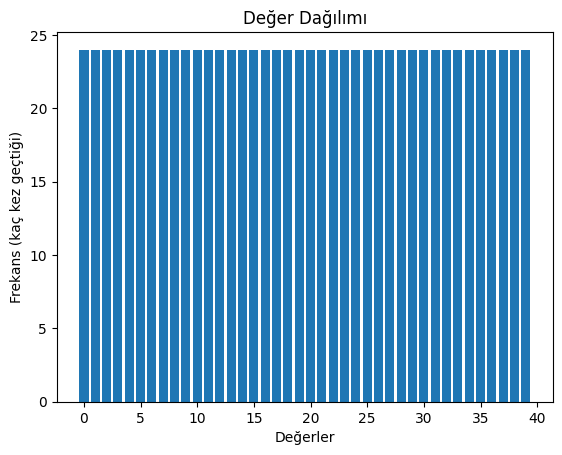

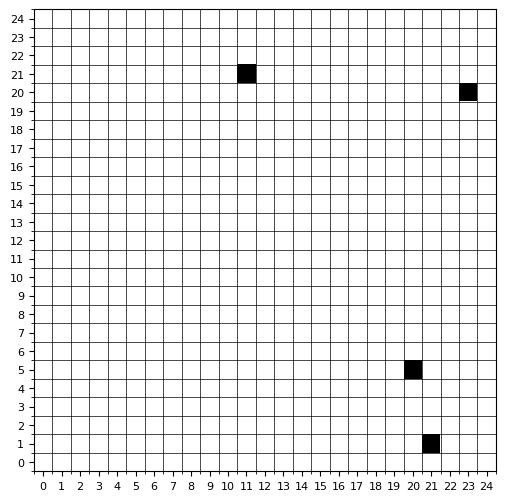

In [162]:
x_train, y_train, x_test, y_test = load_dataset('E')
values, counts = np.unique(y_train, return_counts=True)
plt.bar(values, counts)
plt.xlabel("Değerler")
plt.ylabel("Frekans (kaç kez geçtiği)")
plt.title("Değer Dağılımı")
plt.show()

plot_mat(x_train[1])